In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs nicely
plt.style.use('default')

In [7]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [8]:
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


The dataset contains 891 passenger records and 12 columns. Some columns contain missing values, particularly Age, Cabin, and Embarked.

In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


The average passenger age is around 29 years. Fare values vary significantly, indicating different ticket classes.

In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Missing values are present in Age, Cabin, and Embarked columns. Cabin has the highest number of missing values.

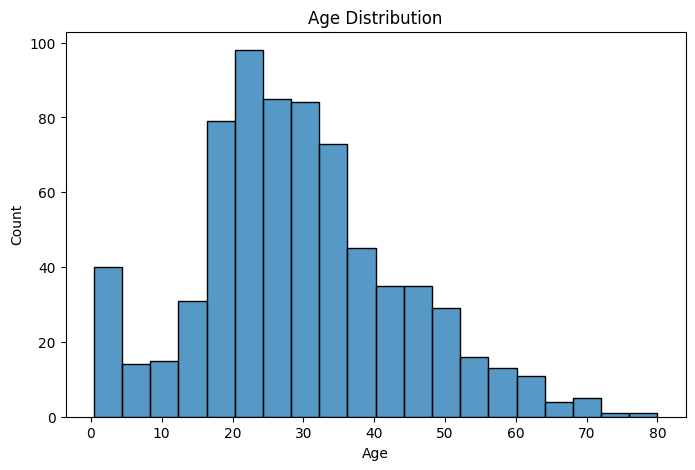

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

Observation:

The majority of passengers were between 20 and 40 years old.
The distribution is slightly right-skewed, meaning there are fewer older passengers compared to younger passengers.
A small number of passengers were children, and very few passengers were above 70 years of age.
This indicates that most travelers on the Titanic were young adults.

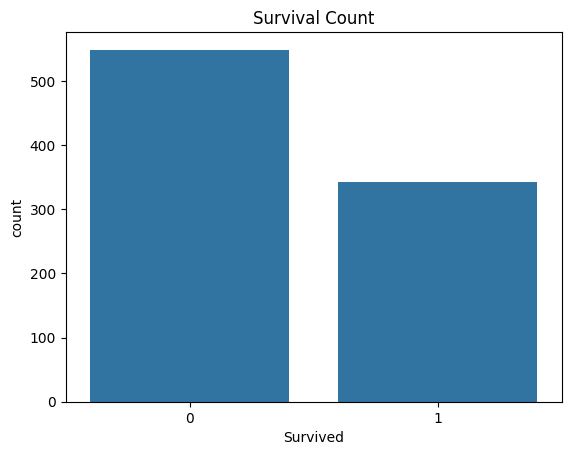

In [16]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

The number of passengers who did not survive is greater than those who survived.

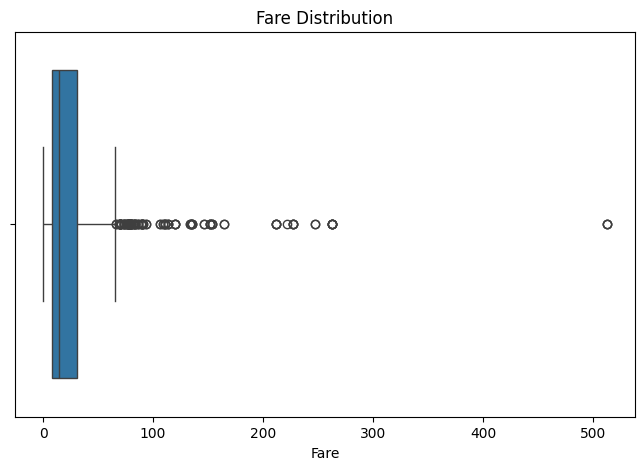

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Fare'])

plt.title("Fare Distribution")

plt.show()

Several extreme fare values are present, indicating outliers in ticket prices.

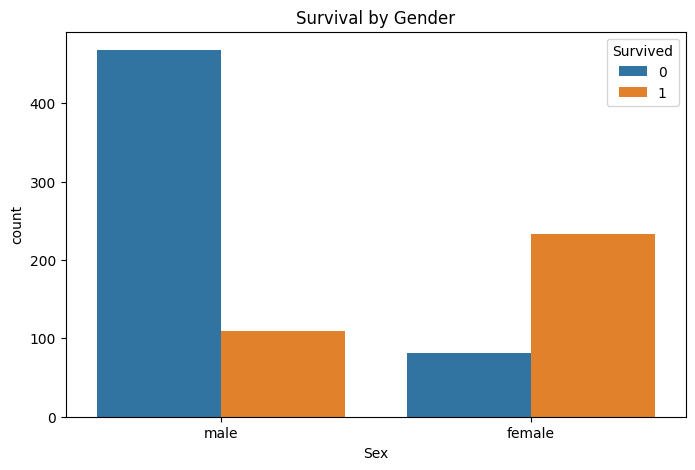

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival by Gender")

plt.show()

Female passengers had a much higher survival rate than male passengers.

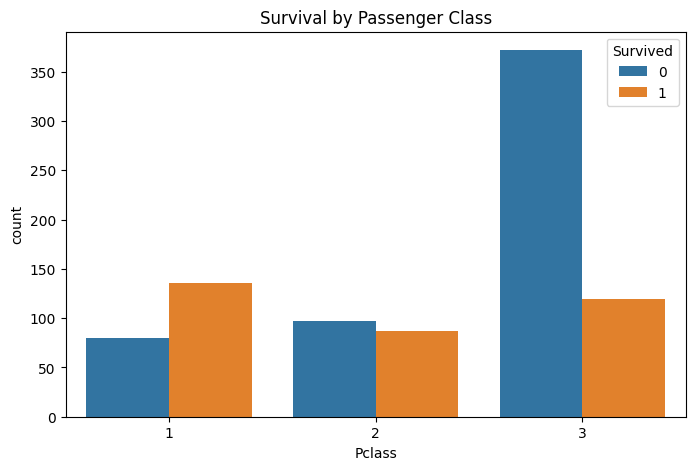

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Survival by Passenger Class")

plt.show()

Passengers in First Class had higher survival chances than those in Second and Third Class.

In [20]:
df2 = df.copy()

df2['Sex'] = df2['Sex'].map({
    'male':0,
    'female':1
})

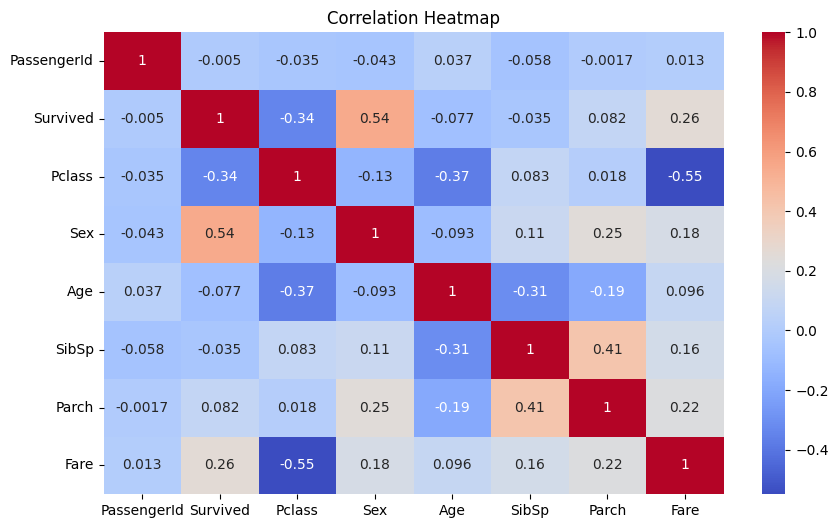

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df2.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Survival is positively correlated with Fare and negatively correlated with Passenger Class.

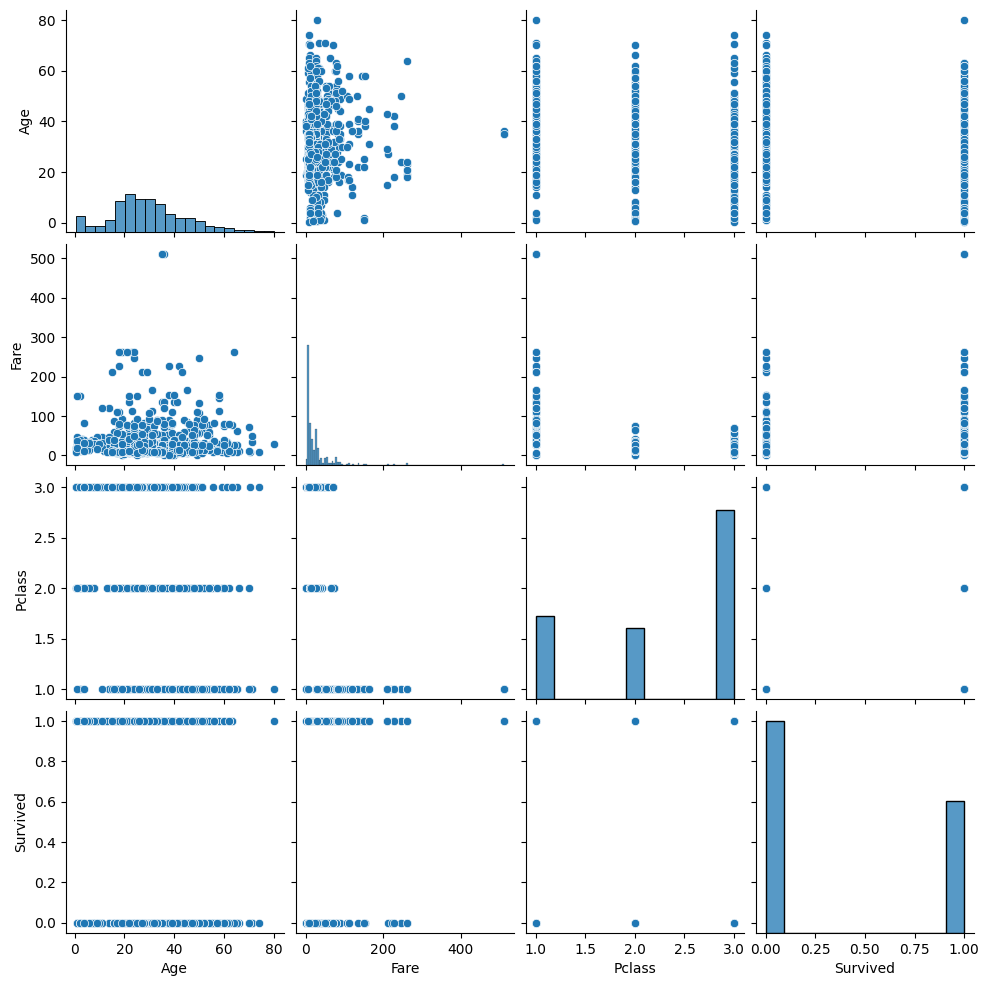

In [22]:
sns.pairplot(
    df[['Age','Fare','Pclass','Survived']]
)

plt.show()

Passenger Class and Fare show noticeable relationships with survival outcomes.

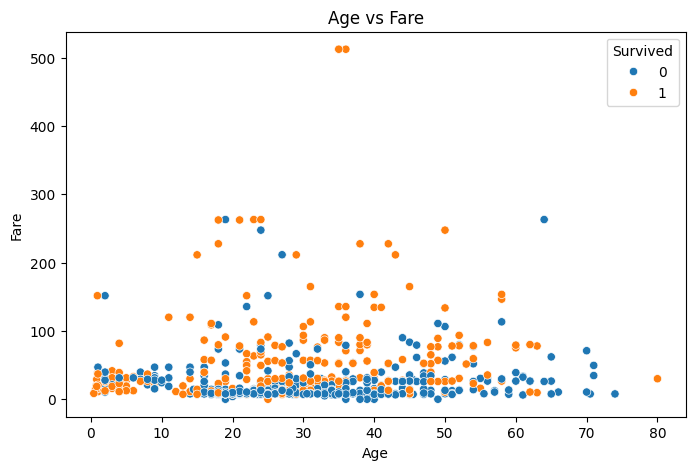

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Fare',
    hue='Survived',
    data=df
)

plt.title("Age vs Fare")

plt.show()

Passengers paying higher fares generally had better survival rates.

SUMMARY OF FINDINGS

1. Most passengers were between 20 and 40 years old.
2. Female passengers had significantly higher survival rates.
3. First Class passengers survived more frequently.
4. Fare contains several outliers.
5. Higher fare values are associated with better survival chances.
6. Passenger Class is an important factor influencing survival.
7. Missing values exist in Age, Cabin and Embarked columns.

CONCLUSION

Exploratory Data Analysis revealed important patterns, trends and relationships in the Titanic dataset. Gender, Passenger Class and Fare were major factors influencing passenger survival.